In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve, f1_score, roc_curve, auc ,fbeta_score, accuracy_score, recall_score,precision_score


import matplotlib.pyplot as plt
from IPython import display
import matplotlib.cm as cm
import pylab as pl

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
df = pd.read_csv("creditcard.csv")
#we are using the "Credit Card Fraud Detection: Anonymized credit card transactions labeled as fraudulent or genuine (https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)"
#dataset

In [3]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


This dataset is labelled, so we can do supervised anomaly detection. However, many of the methods we went over in class are unsupervised, so when specified, we will just use the labels for evalutation and not training.

An anomaly in this dataset is a fraudulent transaction, these are labelled 1 in the row of each entry.

This dataset is VERY unbalanced. Meaning that certain techniques will need to be used in order to account for this

We will be using 3 methods

One statistical method: Z-score thresholding

One distance based method: kNN

One ML method: One-Class SVM

## Statistical Method

In [4]:
#for the statistical method we will use z-score thresholding. Here we use the labels to isolate only the normal data to train on, then use the labelled data to tune the threshold, and then test
#train/val/test setup
#semi-supervised

#isolate features
features = [col for col in df.columns if col not in ["Class", "Time"]]
X = df[features]
y = df["Class"]

In [5]:
#but amount is different from all the other PCA components, so it might not play nice with everything else. 
#we'll make two models, one with amount and one without

X_na = X.iloc[:,:-1]

In [6]:
X1, X_test, y1, y_test = train_test_split(X, y, test_size=0.2, random_state=99, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X1, y1, test_size=0.25, random_state=99, stratify=y1)

In [7]:
print("Train size:", len(X_train))
print("Val size:  ", len(X_val))
print("Test size: ", len(X_test))

Train size: 170883
Val size:   56962
Test size:  56962


In [8]:
#isolate only normal (non-anomolous) entries
X_train_normal = X_train[y_train == 0]

mu = X_train_normal.mean()
sigma = X_train_normal.std(ddof=0)

z_scores = (X_val - mu) / sigma
abs_z = np.abs(z_scores)

In [9]:
scores = abs_z.max(axis=1)

In [10]:
#Tune threshold by optimizing for F1
thresholds = np.linspace(2.0, 25.0, 1000)
best_f1 = -1
best_threshold = None

for t in thresholds:
    preds = (scores > t).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 15.123123123123124
Best F1: 0.23076923076923075


              precision    recall  f1-score   support

           0     0.9988    0.9978    0.9983     56864
           1     0.2025    0.3265    0.2500        98

    accuracy                         0.9966     56962
   macro avg     0.6007    0.6622    0.6242     56962
weighted avg     0.9975    0.9966    0.9970     56962



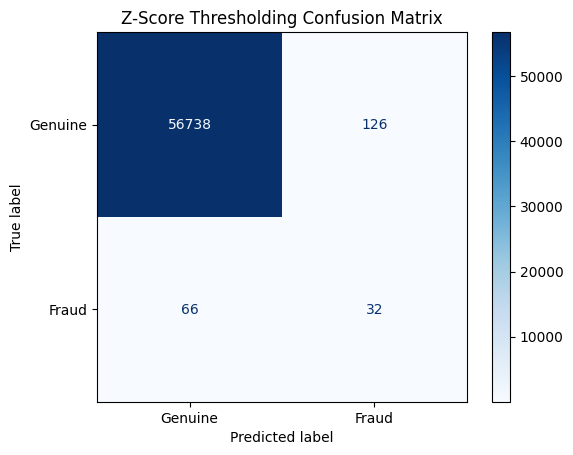

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

z_scores_test = (X_test - mu) / sigma
abs_z = np.abs(z_scores_test)
scores_test = abs_z.max(axis=1)

y_test_pred = (scores_test > best_threshold).astype(int)

print(classification_report(y_test, y_test_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Genuine", "Fraud"])

disp.plot(cmap="Blues", values_format="d")
plt.title("Z-Score Thresholding Confusion Matrix")
plt.show()

above matrix has shape 

[TN  FP]

[FN  TP]

In [12]:


# Confusion matrix entries
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

# Metrics
fpr_base = fp / (fp + tn) if (fp + tn) > 0 else 0
tpr_base = tp / (tp + fn) if (tp + fn) > 0 else 0   # same as recall
accuracy_base = accuracy_score(y_test, y_test_pred)
recall_base = recall_score(y_test, y_test_pred, zero_division=0)
prec_base = precision_score(y_test, y_test_pred, zero_division=0)
f1_base = f1_score(y_test, y_test_pred, zero_division=0)

print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")
print(f"FPR: {fpr_base:.4f}")
print(f"TPR: {tpr_base:.4f}")
print(f"Accuracy: {accuracy_base:.4f}")
print(f"Precision = {prec_base:.4f}")
print(f"Recall: {recall_base:.4f}")
print(f"F1: {f1:.4f}")

TN: 56738
FP: 126
FN: 66
TP: 32
FPR: 0.0022
TPR: 0.3265
Accuracy: 0.9966
Precision = 0.2025
Recall: 0.3265
F1: 0.1769


Here, we can see an issue with F1 score and precision on our very unbalanced dataset.

Because precision = TP/(TP+FP), and there are so few true positives in our dataset (only 88 in our testing set vs 56864 true negatives), unless the model is performining perfectly, there is very high potential for false positives to overwhelm precision.

As an example, if the model had a false positive rate of 1%, that would still leave 568 false positives compared to a maximum of 88 positives total. Making the recall score terrible even though 99% of transactions are working exactly as intended. This means that precision and therefore F1 are not very useful for this dataset. To combat this, we can heavily bias TPR. We can say this because in a case like credit card fraud you can compare the impact of catching true positives vs dealing with false positives.

Accidently marking a false positive has very low downside, maybe the user gets an SMS message asking them to verify the purchase, and then they move on.

Accidently missing a true positive can lead to massive consequences, the user has to notice the fraud themselves, call the bank, the transaction has to be reversed, and then the user might have to potentially deal with other consequences of having someone able to make fraudulent purcahses (identity fraud, etc).

Knowing this, we can make a guess for how much more important catching true positives is vs false positives. Say it's 100x more important, for this we can use an Fbeta with beta = 10. 

In [13]:
thresholds = np.linspace(2.0, 25.0, 1000)
best_f10 = -1
best_threshold = None

for t in thresholds:
    preds = (scores > t).astype(int)
    f10 = fbeta_score(y_val, preds, beta=10, zero_division=0)

    if f10 > best_f10:
        best_f10 = f10
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best F10:", best_f10)

Best threshold: 5.683683683683684
Best F10: 0.678331565924355


              precision    recall  f1-score   support

           0     0.9997    0.9771    0.9883     56864
           1     0.0598    0.8469    0.1118        98

    accuracy                         0.9768     56962
   macro avg     0.5298    0.9120    0.5500     56962
weighted avg     0.9981    0.9768    0.9868     56962



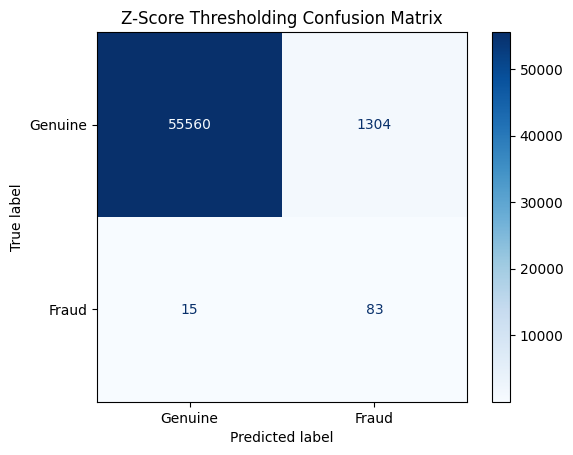

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

z_scores_test = (X_test - mu) / sigma
abs_z = np.abs(z_scores_test)
scores_test = abs_z.max(axis=1)

y_test_pred = (scores_test > best_threshold).astype(int)

print(classification_report(y_test, y_test_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Genuine", "Fraud"])

disp.plot(cmap="Blues", values_format="d")
plt.title("Z-Score Thresholding Confusion Matrix")
plt.show()

In [15]:


# Confusion matrix entries
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

# Metrics
fpr_base = fp / (fp + tn) if (fp + tn) > 0 else 0
tpr_base = tp / (tp + fn) if (tp + fn) > 0 else 0   # same as recall
accuracy_base = accuracy_score(y_test, y_test_pred)
recall_base = recall_score(y_test, y_test_pred, zero_division=0)
prec_base = precision_score(y_test, y_test_pred, zero_division=0)
f1_base = f1_score(y_test, y_test_pred, zero_division=0)

print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")
print(f"FPR: {fpr_base:.4f}")
print(f"TPR: {tpr_base:.4f}")
print(f"Accuracy: {accuracy_base:.4f}")
print(f"Precision = {prec_base:.4f}")
print(f"Recall: {recall_base:.4f}")
print(f"F1: {f1:.4f}")

TN: 55560
FP: 1304
FN: 15
TP: 83
FPR: 0.0229
TPR: 0.8469
Accuracy: 0.9768
Precision = 0.0598
Recall: 0.8469
F1: 0.1769


now, we have almost tripled our TPR, and kept FPR under 97%. This is likely a much more useful model for a real fraud detection program, even though F1 score is far worse 

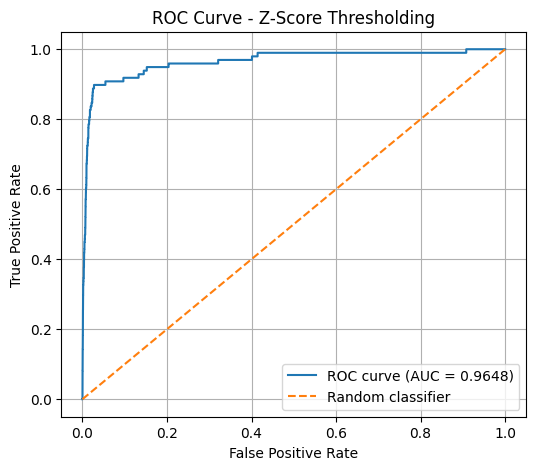

In [16]:
fpr, tpr, roc_thresholds = roc_curve(y_test, scores_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Z-Score Thresholding")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
#repeat for dataset without amount included
X1, X_test, y1, y_test = train_test_split(X_na, y, test_size=0.2, random_state=99, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X1, y1, test_size=0.25, random_state=99, stratify=y1)
#isolate only normal (non-anomolous) entries
X_train_normal = X_train[y_train == 0]
mu = X_train_normal.mean()
sigma = X_train_normal.std(ddof=0)
z_scores = (X_val - mu) / sigma
abs_z = np.abs(z_scores)
scores = abs_z.max(axis=1)
#Tune threshold
thresholds = np.linspace(2, 25.0, 1000)
best_f10 = -26
best_threshold = None

for t in thresholds:
    preds = (scores > t).astype(int)
    f10 = fbeta_score(y_val, preds, beta=10, zero_division=0)
    if f10 > best_f10:
        best_f10 = f10
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best F1:", best_f10)
z_scores_test = (X_test - mu) / sigma
abs_z = np.abs(z_scores_test)
scores_test = abs_z.max(axis=1)

Best threshold: 5.683683683683684
Best F1: 0.6839525973447385


              precision    recall  f1-score   support

           0     0.9997    0.9784    0.9889     56864
           1     0.0632    0.8469    0.1176        98

    accuracy                         0.9781     56962
   macro avg     0.5314    0.9126    0.5532     56962
weighted avg     0.9981    0.9781    0.9874     56962



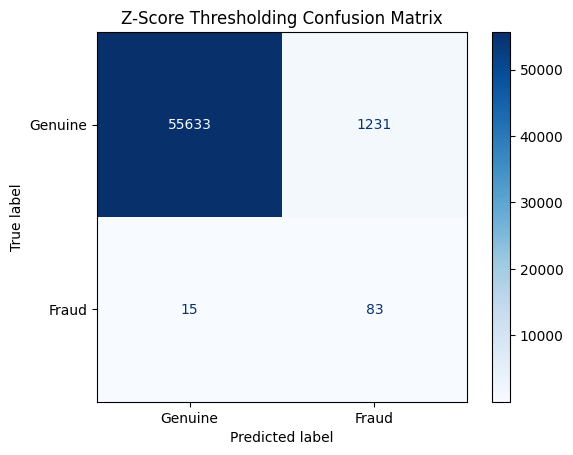

In [18]:
y_test_pred = (scores_test > best_threshold).astype(int)

print(classification_report(y_test, y_test_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Genuine", "Fraud"])

disp.plot(cmap="Blues", values_format="d")
plt.title("Z-Score Thresholding Confusion Matrix")
plt.show()

In [19]:


# Confusion matrix entries
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

# Metrics
fpr_na = fp / (fp + tn) if (fp + tn) > 0 else 0
tpr_na = tp / (tp + fn) if (tp + fn) > 0 else 0   # same as recall
accuracy_na = accuracy_score(y_test, y_test_pred)
recall_na = recall_score(y_test, y_test_pred, zero_division=0)
prec_na = precision_score(y_test, y_test_pred, zero_division=0)
f1_na = f1_score(y_test, y_test_pred, zero_division=0)

print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")
print(f"FPR: {fpr_na:.4f}")
print(f"TPR: {tpr_na:.4f}")
print(f"Accuracy: {accuracy_na:.4f}")
print(f"Precision = {prec_na:.4f}")
print(f"Recall: {recall_na:.4f}")
print(f"F1: {f1_na:.4f}")

TN: 55633
FP: 1231
FN: 15
TP: 83
FPR: 0.0216
TPR: 0.8469
Accuracy: 0.9781
Precision = 0.0632
Recall: 0.8469
F1: 0.1176


In [20]:
fpr

array([0.00000000e+00, 1.75858188e-05, 1.58272369e-04, ...,
       9.97450056e-01, 9.97485228e-01, 1.00000000e+00])

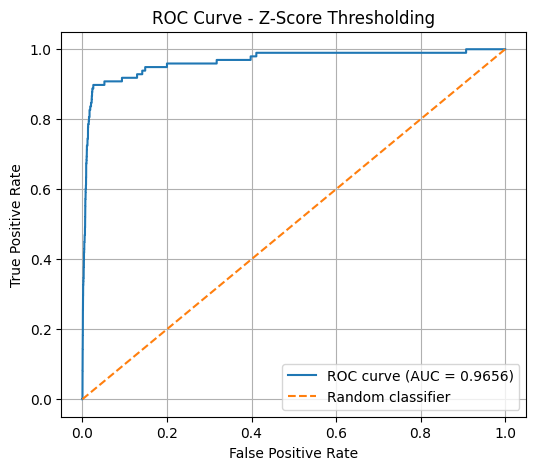

In [22]:
fpr, tpr, roc_thresholds = roc_curve(y_test, scores_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Z-Score Thresholding")
plt.legend()
plt.grid(True)
plt.show()

Worth noting that all these ROC curves look very good, but that's mainly because the false negative rate is very low unless the threshold is very high, due to how unbalanced the dataset is. 

In [23]:
metrics = {
    "FPR": (fpr_base, fpr_na),
    "TPR": (tpr_base, tpr_na),
    "Accuracy": (accuracy_base, accuracy_na),
    "Recall": (recall_base, recall_na),
    "Precision": (prec_base, prec_na),
    "F1": (f1_base, f1_na),
}

print(f"{'Metric':<10} {'Normal':>10} {'WithoutAmount':>10} {'Diff':>10} {'Result':>12}")
print("-" * 58)

for name, (base, na) in metrics.items():
    diff = na - base
    
    if name == "FPR":
        result = "Better" if na < base else "Worse" if na > base else "Same"
    else:
        result = "Better" if na > base else "Worse" if na < base else "Same"
    
    print(f"{name:<10} {base:>10.4f} {na:>10.4f} {diff:>10.4f} {result:>12}")

Metric         Normal WithoutAmount       Diff       Result
----------------------------------------------------------
FPR            0.0229     0.0216    -0.0013       Better
TPR            0.8469     0.8469     0.0000         Same
Accuracy       0.9768     0.9781     0.0013       Better
Recall         0.8469     0.8469     0.0000         Same
Precision      0.0598     0.0632     0.0033       Better
F1             0.1118     0.1176     0.0058       Better


If you exclude amount, results are better or the same across the board, so it's probably best not to include it